In [1]:
# read data
import pandas as pd

articles = pd.read_csv('Flatfeet_clean.csv')
columns = ['Title', 'Author', 'Publication Year', 'Abstract Note', 'Journal Abbreviation',]
articles = articles[columns]
ids = list(range(1, len(articles) + 1))
articles['id'] = ids
abstracts = articles['Abstract Note'].tolist()
abstract_dict = dict(zip(articles['id'], abstracts))
article_ids = articles['id'].tolist()

In [2]:
from gliner2 import GLiNER2

# Load the model
extractor = GLiNER2.from_pretrained("fastino/gliner2-large-v1")


2026-03-18 11:36:31.428557123 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"
/home/homeless/.virtualenvs/ts_lab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-large
Counting layer     : count_lstm
Token pooling      : first


In [ ]:
import json


all_results = {}

fields = [
    'Anatomical Entity',
    'Symptom',
    'Terms of Body Movements',
    'Population',
]

round_one_schema = {
    'Anatomical Entity': 'Any structure within a biological organism.',
    'Symptom': 'Medical symptoms, conditions, and clinically relevant complaints.',
    'Terms of Body Movements': "Movements, biomechanical measures, postures, alignments, and motion phrases like 'ankle dorsiflexion' or 'hip internal rotation'.",
    'Population': 'The population of interest, including age, sex, sample size, clinical status, and study groups.',
    'Measurement': 'Any measurement, metric, or outcome related to the study, such as kinematic measures, kinetic measures, EMG measures, or clinical outcomes.',
}

round_two_schemas = {
    'Symptom': {
        'anatomical structure': 'Where is the symptom located?',
        'symptom': 'What is the symptom, diagnosis, or condition?',
    },
    'Terms of Body Movements': {
        'anatomical structure': 'Which anatomical structure is involved in the movement?',
        'movement': 'What is the movement, posture, alignment, or biomechanical measure?',
    },
    'Population': {
        'age': 'Age, age range, or developmental stage.',
        'level': 'Athelete level, activity level, fitness level, or non-athlete.',
        'clinical status': 'Clinical condition, case/control status, or disease status.',
        'sex': 'Sex or gender.',
        'sample size': 'Sample size, counts, or number of participants.',
        'study group': 'Named cohort, subgroup, or study arm.',
    },
}


def extract_round_one_entities(text):
    return extractor.extract_entities(text, round_one_schema).get('entities', {})


for i, text in enumerate(abstracts, start=1):
    if pd.isna(text) or str(text).strip() == '':
        print(f'[{i}] skipped: empty abstract')
        all_results[str(i)] = {}
        continue

    round_one_entities = extract_round_one_entities(text)
    all_results[str(i)] = round_one_entities


with open('entities_pretrainedmodel.json', 'w') as f:
    json.dump(all_results, f, indent=4)


In [6]:
# result analysis

with open('normalized_entities.json', 'r') as f:
    normalized_entity_data = json.load(f)

round_two_lookup = normalized_entity_data['round2_lookup']
abstract_aggregated_entities = normalized_entity_data['abstracts']


def _is_empty_list(value):
    return not value


def _all_round2_fields_empty(attributes):
    return all(_is_empty_list(values) for values in attributes.values())


symptom_missing_anatomy = []
movement_missing_anatomy = []
population_all_empty = []
symptom_total = 0
movement_total = 0
population_total = 0

for record in abstract_aggregated_entities:
    abstract_id = record['abstract']['abstract_id']
    for entity in record['entities']:
        field = entity['field']
        entity_form = entity['entity_form']
        attributes = round_two_lookup.get(field, {}).get(entity_form)
        if not attributes:
            continue

        item = {
            'abstract_id': abstract_id,
            'entity_form': entity_form,
            'mention': entity['mention'],
            'attributes': attributes,
        }

        if field == 'Symptom':
            symptom_total += 1
            if _is_empty_list(attributes.get('anatomical structure', [])):
                symptom_missing_anatomy.append(item)
        elif field == 'Terms of Body Movements':
            movement_total += 1
            has_movement = not _is_empty_list(attributes.get('movement', []))
            missing_anatomy = _is_empty_list(attributes.get('anatomical structure', []))
            if has_movement and missing_anatomy:
                movement_missing_anatomy.append(item)
        elif field == 'Population':
            population_total += 1
            if _all_round2_fields_empty(attributes):
                population_all_empty.append(item)

round2_analysis = {
    'symptom_without_anatomical_structure': {
        'count': len(symptom_missing_anatomy),
        'percentage': (len(symptom_missing_anatomy) / symptom_total * 100) if symptom_total else 0,
        'items': symptom_missing_anatomy,
    },
    'movement_without_anatomical_structure': {
        'count': len(movement_missing_anatomy),
        'percentage': (len(movement_missing_anatomy) / movement_total * 100) if movement_total else 0,
        'items': movement_missing_anatomy,
    },
    'population_with_all_empty_round2_fields': {
        'count': len(population_all_empty),
        'percentage': (len(population_all_empty) / population_total * 100) if population_total else 0,
        'items': population_all_empty,
    },
}

for key, value in round2_analysis.items():
    print(f"{key}: {value['count']} ({value['percentage']:.2f}%)")

round2_analysis


symptom_without_anatomical_structure: 0 (0.00%)
movement_without_anatomical_structure: 0 (0.00%)
population_with_all_empty_round2_fields: 1 (100.00%)


{'symptom_without_anatomical_structure': {'count': 0,
  'percentage': 0.0,
  'items': []},
 'movement_without_anatomical_structure': {'count': 0,
  'percentage': 0.0,
  'items': []},
 'population_with_all_empty_round2_fields': {'count': 1,
  'percentage': 100.0,
  'items': [{'abstract_id': 'abs_001',
    'entity_form': 'young adult',
    'mention': {'original_text': 'young adults', 'position': None},
    'attributes': {'age': [],
     'level': [],
     'clinical status': [],
     'sex': [],
     'sample size': [],
     'study group': []}}]}}

In [11]:
# entity normalization
# build raw canonical records first, then project them into normalized forms

import re
from collections import defaultdict

ABBREVIATION_MAP = {
    'AP': 'anterior-posterior',
    'BF': 'biceps femoris',
    'BFFG': 'bilateral flexible flat feet group',
    'KF': 'knee flexion',
    'LBP': 'low back pain',
    'MG': 'medial gastrocnemius',
    'MLBP': 'mechanical low back pain',
    'MTSS': 'medial tibial stress syndrome',
    'NFG': 'normal foot group',
    'OA': 'osteoarthritis',
    'OFFG': 'one-sided flexible flat feet group',
    'PF': 'plantar fasciitis',
    'PFP': 'patellofemoral pain',
    'PFPS': 'patellofemoral pain syndrome',
    'RF': 'rectus femoris',
    'TA': 'tibialis anterior',
}

IRREGULAR_SINGULARS = {
    'feet': 'foot',
    'teeth': 'tooth',
    'men': 'man',
    'women': 'woman',
    'children': 'child',
    'people': 'person',
    'indices': 'index',
}

SINGULAR_OVERRIDES = {
    'alignments': 'alignment',
    'analyses': 'analysis',
    'angles': 'angle',
    'areas': 'area',
    'changes': 'change',
    'controls': 'control',
    'deformations': 'deformation',
    'disorders': 'disorder',
    'extremities': 'extremity',
    'factors': 'factor',
    'flexions': 'flexion',
    'grades': 'grade',
    'imbalances': 'imbalance',
    'individuals': 'individual',
    'joints': 'joint',
    'knees': 'knee',
    'limbs': 'limb',
    'measures': 'measure',
    'motions': 'motion',
    'muscles': 'muscle',
    'parameters': 'parameter',
    'patients': 'patient',
    'pathologies': 'pathology',
    'planes': 'plane',
    'postures': 'posture',
    'pressures': 'pressure',
    'referees': 'referee',
    'runners': 'runner',
    'scores': 'score',
    'subjects': 'subject',
    'symptoms': 'symptom',
    'torsions': 'torsion',
    'volunteers': 'volunteer',
}

TOKEN_SPLIT_PATTERN = re.compile(r'([\s/(),]+)')


In [12]:
def _tokenize_with_spans(text):
    return list(re.finditer(r'\S+', text))


def _char_to_start_token(token_matches, start_char):
    start_token = None

    for token_idx, token in enumerate(token_matches):
        if start_token is None and token.start() <= start_char < token.end():
            start_token = token_idx
            break

    return start_token


def _collect_match_positions(text, token_matches, entity_text, ignore_case=False):
    flags = re.IGNORECASE if ignore_case else 0
    positions = []

    for match in re.finditer(re.escape(entity_text), text, flags=flags):
        start_token = _char_to_start_token(token_matches, match.start())
        if start_token is not None:
            positions.append(start_token)

    return positions


def _is_abbreviation(text):
    letters = [char for char in text if char.isalpha()]
    return bool(letters) and all(char.isupper() for char in letters)


def _singularize_word(word):
    if not word or _is_abbreviation(word):
        return word

    lower_word = word.lower()
    if lower_word in IRREGULAR_SINGULARS:
        return IRREGULAR_SINGULARS[lower_word]
    if lower_word in SINGULAR_OVERRIDES:
        return SINGULAR_OVERRIDES[lower_word]
    if len(lower_word) <= 3:
        return lower_word
    if lower_word.endswith('ies') and len(lower_word) > 4:
        return lower_word[:-3] + 'y'
    if lower_word.endswith('sses') or lower_word.endswith('xes') or lower_word.endswith('zes'):
        return lower_word[:-2]
    if lower_word.endswith('s') and not lower_word.endswith('ss'):
        return lower_word[:-1]
    return lower_word


def _expand_abbreviation_token(token):
    if not token or TOKEN_SPLIT_PATTERN.fullmatch(token):
        return token

    if _is_abbreviation(token):
        return ABBREVIATION_MAP.get(token, token.lower())

    return token.lower()


def _normalize_token(token):
    if not token or TOKEN_SPLIT_PATTERN.fullmatch(token):
        return token

    return _singularize_word(token)


def _normalize_hyphen_spacing(text):
    return re.sub(r'(?<!\d)-(?!\d)|(?<!\d)-(?=\d)|(?<=\d)-(?!\d)', ' ', text)


def _normalize_canonical_form(text, field):
    if not text or not text.strip():
        return None

    normalized = _normalize_hyphen_spacing(text.strip())
    normalized = ''.join(_expand_abbreviation_token(part) for part in TOKEN_SPLIT_PATTERN.split(normalized))
    normalized = ''.join(_normalize_token(part) for part in TOKEN_SPLIT_PATTERN.split(normalized))
    normalized = re.sub(r'\s+', ' ', normalized).strip(' -/(),')

    if field == 'Anatomical Entity':
        if normalized == 'joint':
            return None
        if normalized.endswith(' joint'):
            normalized = normalized[:-6].strip()
            if not normalized:
                return None
        if normalized.startswith('left '):
            normalized = normalized[5:].strip()
        elif normalized.startswith('right '):
            normalized = normalized[6:].strip()
        if not normalized:
            return None

    return normalized or None



In [13]:

def build_canonical_entities(abstracts_dict, entity_dict):
    """Build raw canonical entity records grouped by exact text within each field."""
    canonical_records = []
    canonical_index = {}

    for abstract_id in sorted(abstracts_dict):
        text = '' if abstracts_dict[abstract_id] is None else str(abstracts_dict[abstract_id])
        abstract_entities = entity_dict.get(str(abstract_id), entity_dict.get(abstract_id, {}))
        token_matches = _tokenize_with_spans(text)

        exact_match_cache = {}
        ignorecase_match_cache = {}

        for field, entities in abstract_entities.items():
            seen_entity_texts = set()
            for entity_text in entities:
                if not isinstance(entity_text, str) or not entity_text.strip():
                    continue

                entity_text = entity_text.strip()
                if entity_text in seen_entity_texts:
                    continue
                seen_entity_texts.add(entity_text)

                if entity_text not in exact_match_cache:
                    exact_match_cache[entity_text] = _collect_match_positions(text, token_matches, entity_text)
                match_positions = exact_match_cache[entity_text]

                if match_positions:
                    positions = match_positions
                else:
                    fallback_key = entity_text.casefold()
                    if fallback_key not in ignorecase_match_cache:
                        ignorecase_match_cache[fallback_key] = _collect_match_positions(
                            text,
                            token_matches,
                            entity_text,
                            ignore_case=True,
                        )
                    positions = ignorecase_match_cache[fallback_key]

                if not positions:
                    positions = [None]

                canonical_key = (field, entity_text)
                if canonical_key not in canonical_index:
                    canonical_index[canonical_key] = len(canonical_records)
                    canonical_records.append({
                        'canonical_id': f'ent_{len(canonical_records) + 1:03d}',
                        'canonical_form': entity_text,
                        'field': field,
                        'variants': [entity_text],
                        'occurrences': [],
                    })

                for position in positions:
                    canonical_records[canonical_index[canonical_key]]['occurrences'].append({
                        'abstract_id': f'abs_{int(abstract_id):03d}',
                        'original_text': entity_text,
                        'position': position,
                    })

    return canonical_records


def normalize_canonical_entities(canonical_entities):
    """Normalize canonical forms and merge duplicates by field plus normalized form."""
    merged_records = {}

    for record in canonical_entities:
        normalized_form = _normalize_canonical_form(record['canonical_form'], record['field'])
        if normalized_form is None:
            continue

        merge_key = (record['field'], normalized_form)
        if merge_key not in merged_records:
            merged_records[merge_key] = {
                'canonical_form': normalized_form,
                'field': record['field'],
                'variants': [],
                'occurrences': [],
            }

        merged_record = merged_records[merge_key]
        for variant in record.get('variants', []):
            if variant not in merged_record['variants']:
                merged_record['variants'].append(variant)

        merged_record['occurrences'].extend(record.get('occurrences', []))

    normalized_records = []
    for idx, merged_record in enumerate(sorted(merged_records.values(), key=lambda item: (item['field'], item['canonical_form'])), start=1):
        normalized_records.append({
            'canonical_id': f'ent_{idx:03d}',
            'canonical_form': merged_record['canonical_form'],
            'field': merged_record['field'],
            'variants': merged_record['variants'],
            'occurrences': merged_record['occurrences'],
        })

    return normalized_records


def build_abstract_aggregated_entities(canonical_entities, abstracts_dict):
    abstract_records = {
        f'abs_{int(abstract_id):03d}': {
            'abstract': {
                'abstract_id': f'abs_{int(abstract_id):03d}',
                'text': '' if abstract_text is None else str(abstract_text),
            },
            'entities': [],
            'output_format': {
                'triples': [],
            },
        }
        for abstract_id, abstract_text in abstracts_dict.items()
    }

    for entity in canonical_entities:
        for occurrence in entity.get('occurrences', []):
            abstract_id = occurrence['abstract_id']
            abstract_records[abstract_id]['entities'].append({
                'entity_id': entity['canonical_id'],
                'entity_form': entity['canonical_form'],
                'field': entity['field'],
                'mention': {
                    'original_text': occurrence['original_text'],
                    'position': occurrence['position'],
                },
            })

    for record in abstract_records.values():
        record['entities'].sort(
            key=lambda item: (
                float('inf') if item['mention']['position'] is None else item['mention']['position'],
                item['entity_id'],
            )
        )

    return list(abstract_records.values())


def build_normalized_abstract_entities(canonical_entities_raw, abstracts_dict):
    normalized_entities = normalize_canonical_entities(canonical_entities_raw)
    return build_abstract_aggregated_entities(normalized_entities, abstracts_dict)


def count_abstract_entity_mentions(abstract_aggregated_entities):
    return sum(len(record['entities']) for record in abstract_aggregated_entities)


def build_round_two_lookup(abstract_aggregated_entities):
    round_two_lookup = {field: {} for field in round_two_schemas}

    for record in abstract_aggregated_entities:
        for entity in record['entities']:
            field = entity['field']
            entity_form = entity['entity_form']
            if field not in round_two_schemas:
                continue
            if entity_form not in round_two_lookup[field]:
                round_two_lookup[field][entity_form] = extractor.extract_entities(
                    entity_form,
                    round_two_schemas[field],
                ).get('entities', {})

    return {field: lookup for field, lookup in round_two_lookup.items() if lookup}


def build_normalized_entity_data(canonical_entities_raw, abstracts_dict):
    abstracts = build_normalized_abstract_entities(canonical_entities_raw, abstracts_dict)
    return {
        'round2_lookup': build_round_two_lookup(abstracts),
        'abstracts': abstracts,
    }


In [14]:
canonical_entities_raw = build_canonical_entities(abstract_dict, all_results)
normalized_entity_data = build_normalized_entity_data(canonical_entities_raw, abstract_dict)
abstract_aggregated_entities = normalized_entity_data['abstracts']
round_two_lookup = normalized_entity_data['round2_lookup']
with open ('normalized_entities.json', 'w') as f:
    json.dump(normalized_entity_data, f, indent=4)

In [1]:
re_gpt5_1 = [
{
"subject": "flat foot",
"relation": "associated_with",
"object": "medial longitudinal arch",
"evidence": "The collapse of medial longitudinal arch is called Flat Foot."
},
{
"subject": "flat foot",
"relation": "associated_with",
"object": "pronated foot",
"evidence": "flat foot is associated with pronated foot"
},
{
"subject": "flat foot",
"relation": "prevalence_in",
"object": "7-14 year of age",
"evidence": "The prevalence of flatfoot is 17.1% in 7-14 years of age"
},
{
"subject": "flat foot",
"relation": "prevalence_in",
"object": "613 year",
"evidence": "16.4% in 613 years"
},
{
"subject": "flat foot",
"relation": "prevalence_in",
"object": "6-12 year of age",
"evidence": "17.2% in 6-12 years of age"
},
{
"subject": "abnormal alignment",
"relation": "contributes_to",
"object": "anterior knee pain",
"evidence": "Idiopathic anterior knee pain in nonathletic population ... is mainly attributed to abnormal alignment"
},
{
"subject": "muscular imbalance",
"relation": "contributes_to",
"object": "anterior knee pain",
"evidence": "Idiopathic anterior knee pain in nonathletic population ... is mainly attributed to abnormal alignment and muscular imbalance"
},
{
"subject": "flat foot",
"relation": "contributes_to",
"object": "anterior knee pain",
"evidence": "Flat foot is one of the contributing factors to development of anterior knee pain."
},
{
"subject": "flat foot",
"relation": "correlated_with",
"object": "anterior knee pain",
"evidence": "there is negative correlation between flatfoot and anterior knee pain"
},
{
"subject": "flat foot",
"relation": "measured_by",
"object": "clarke' angle",
"evidence": "Clarke’s Angle was measured from the foot print"
},
{
"subject": "anterior knee pain",
"relation": "measured_by",
"object": "kujala score",
"evidence": "Kujala Score was calculated from the Google form"
},
{
"subject": "anterior knee pain",
"relation": "located_in",
"object": "knee",
"evidence": "anterior knee pain"
},
{
"subject": "pronated foot",
"relation": "located_in",
"object": "foot",
"evidence": "pronated foot"
},
{
"subject": "flat foot",
"relation": "located_in",
"object": "foot",
"evidence": "flat foot"
},
{
"subject": "malalign",
"relation": "located_in",
"object": "knee",
"evidence": "can malalign the knee joint"
},
{
"subject": "biomechanic of knee joint",
"relation": "located_in",
"object": "knee",
"evidence": "alter the biomechanics of knee joint"
},
{
"subject": "clarke' angle",
"relation": "correlated_with",
"object": "anterior knee pain",
"evidence": "More reduction of Clarke’s angle, more the severity of anterior knee pain."
}
]

re_gpt5_2 = [
  {
    "subject": "joint congruence",
    "relation": "correlated_with",
    "object": "ankle motion",
    "evidence": "the magnitude of ankle motion is influenced by joint congruence"
  },
  {
    "subject": "ligament elasticity",
    "relation": "correlated_with",
    "object": "ankle motion",
    "evidence": "the magnitude of ankle motion is influenced by ... ligament elasticity"
  },
  {
    "subject": "ankle stiffness",
    "relation": "associated_with",
    "object": "flat foot",
    "evidence": "lack of understanding on ankle stiffness between subjects with and without flat foot"
  },
  {
    "subject": "flat foot",
    "relation": "located_in",
    "object": "foot",
    "evidence": "flat foot"
  },
  {
    "subject": "ankle motion",
    "relation": "located_in",
    "object": "ankle",
    "evidence": "ankle motion"
  },
  {
    "subject": "ankle stiffness",
    "relation": "located_in",
    "object": "ankle",
    "evidence": "ankle stiffness"
  },
  {
    "subject": "ankle stiffness",
    "relation": "correlated_with",
    "object": "dorsiflexion",
    "evidence": "increased stiffness during ankle dorsiflexion"
  },
  {
    "subject": "ankle stiffness",
    "relation": "correlated_with",
    "object": "plantar flexion",
    "evidence": "no significant group difference during plantar flexion"
  },
  {
    "subject": "dorsiflexion",
    "relation": "located_in",
    "object": "ankle",
    "evidence": "ankle dorsiflexion"
  },
  {
    "subject": "plantar flexion",
    "relation": "located_in",
    "object": "ankle",
    "evidence": "plantar flexion"
  },
  {
    "subject": "joint stiffness measure",
    "relation": "measured_by",
    "object": "kinematic analysis",
    "evidence": "need for kinematic analyses and joint stiffness measures during ankle dorsiflexion"
  }
]

re_gpt5_3 = [
  {
    "subject": "abnormal foot posture",
    "relation": "contributes_to",
    "object": "plantar fasciiti",
    "evidence": "Abnormal foot posture ... are potential causes of plantar fasciitis"
  },
  {
    "subject": "muscle performance",
    "relation": "contributes_to",
    "object": "plantar fasciiti",
    "evidence": "poor muscle performance are potential causes of plantar fasciitis"
  },
  {
    "subject": "muscle performance",
    "relation": "located_in",
    "object": "lower extremity",
    "evidence": "lower extremity muscle performance"
  },
  {
    "subject": "foot pressure",
    "relation": "located_in",
    "object": "foot",
    "evidence": "foot pressure"
  },
  {
    "subject": "flat foot posture",
    "relation": "associated_with",
    "object": "foot posture",
    "evidence": "flat foot postures"
  },
  {
    "subject": "plantar heel pain",
    "relation": "located_in",
    "object": "foot",
    "evidence": "plantar heel pain"
  },
  {
    "subject": "muscle strength",
    "relation": "located_in",
    "object": "hip",
    "evidence": "The hip muscle strength was measured"
  },
  {
    "subject": "reaction time",
    "relation": "associated_with",
    "object": "quadricep",
    "evidence": "reaction time of the quadriceps"
  },
  {
    "subject": "reaction time",
    "relation": "associated_with",
    "object": "hamstring",
    "evidence": "reaction time of the ... hamstring"
  },
  {
    "subject": "reaction time",
    "relation": "associated_with",
    "object": "plantar flexor",
    "evidence": "reaction time of the ... plantar flexor muscles"
  },
  {
    "subject": "foot pressure parameter",
    "relation": "measured_by",
    "object": "pedobarography",
    "evidence": "Foot pressure parameters were assessed using pedobarography"
  },
  {
    "subject": "muscle performance",
    "relation": "associated_with",
    "object": "plantar fasciiti",
    "evidence": "differences in muscle performance between patients who have PF"
  }
]

re_gpt5_4 = [
  {
    "subject": "obesity",
    "relation": "contributes_to",
    "object": "mechanical low back pain",
    "evidence": "well-established risk factors such as obesity"
  },
  {
    "subject": "core muscle strength",
    "relation": "contributes_to",
    "object": "mechanical low back pain",
    "evidence": "well-established risk factors such as ... core muscle strength"
  },
  {
    "subject": "pes planu",
    "relation": "associated_with",
    "object": "flat foot",
    "evidence": "pes planus (flat foot)"
  },
  {
    "subject": "flat foot",
    "relation": "associated_with",
    "object": "mechanical low back pain",
    "evidence": "investigate the association between flat foot and MLBP"
  },
  {
    "subject": "flat foot",
    "relation": "contributes_to",
    "object": "mechanical low back pain",
    "evidence": "flat foot is an independent risk factor for MLBP"
  },
  {
    "subject": "mechanical low back pain",
    "relation": "associated_with",
    "object": "low back pain",
    "evidence": "Mechanical low back pain (MLBP)"
  },
  {
    "subject": "flat foot",
    "relation": "located_in",
    "object": "foot",
    "evidence": "flat foot"
  },
  {
    "subject": "foot posture",
    "relation": "located_in",
    "object": "foot",
    "evidence": "foot posture"
  },
  {
    "subject": "foot posture",
    "relation": "measured_by",
    "object": "clarke' angle",
    "evidence": "using Clarke’s angle as an objective measure of foot posture"
  },
  {
    "subject": "altered spinal biomechanic",
    "relation": "located_in",
    "object": "spinal",
    "evidence": "altered spinal biomechanics"
  },
  {
    "subject": "flat foot",
    "relation": "contributes_to",
    "object": "altered spinal biomechanic",
    "evidence": "likely due to altered spinal biomechanics"
  },
  {
    "subject": "flat foot",
    "relation": "contributes_to",
    "object": "compensatory postural change",
    "evidence": "likely due to ... compensatory postural changes"
  }
]

re_gpt5_5 = [
  {
    "subject": "rotational abnormality",
    "relation": "located_in",
    "object": "lower limb",
    "evidence": "identify rotational abnormalities of the lower limb"
  },
  {
    "subject": "primary symptomatic flatfoot",
    "relation": "associated_with",
    "object": "flat foot",
    "evidence": "primary symptomatic flatfoot"
  },
  {
    "subject": "flat foot",
    "relation": "located_in",
    "object": "foot",
    "evidence": "radiographs of the flat foot"
  },
  {
    "subject": "rotation of the lower limb",
    "relation": "located_in",
    "object": "lower limb",
    "evidence": "rotation of the lower limbs"
  },
  {
    "subject": "femoral torsion",
    "relation": "located_in",
    "object": "femur",
    "evidence": "femoral torsion"
  },
  {
    "subject": "tibial torsion",
    "relation": "located_in",
    "object": "tibial",
    "evidence": "tibial torsion"
  },
  {
    "subject": "tibiofemoral rotation",
    "relation": "associated_with",
    "object": "femur",
    "evidence": "tibiofemoral rotation"
  },
  {
    "subject": "tibiofemoral rotation",
    "relation": "associated_with",
    "object": "tibial",
    "evidence": "tibiofemoral rotation"
  },
  {
    "subject": "hip and knee parameter",
    "relation": "associated_with",
    "object": "hip",
    "evidence": "hip and knee parameters"
  },
  {
    "subject": "hip and knee parameter",
    "relation": "associated_with",
    "object": "knee",
    "evidence": "hip and knee parameters"
  }
]


re_gpt5_6 = [
  {
    "subject": "muscle tone",
    "relation": "located_in",
    "object": "leg muscle",
    "evidence": "muscle tone and stiffness of leg muscles"
  },
  {
    "subject": "stiffness",
    "relation": "located_in",
    "object": "leg muscle",
    "evidence": "muscle tone and stiffness of leg muscles"
  },
  {
    "subject": "flexible flat foot",
    "relation": "associated_with",
    "object": "muscle tone",
    "evidence": "examine differences in the muscle tone ... according to types of flexible flat foot"
  },
  {
    "subject": "flexible flat foot",
    "relation": "associated_with",
    "object": "stiffness",
    "evidence": "examine differences in the muscle tone and stiffness ... according to types of flexible flat foot"
  },
  {
    "subject": "muscle tone",
    "relation": "located_in",
    "object": "tibiali anterior muscle",
    "evidence": "measure the muscle tone ... of the tibialis anterior muscle"
  },
  {
    "subject": "stiffness",
    "relation": "located_in",
    "object": "tibiali anterior muscle",
    "evidence": "measure the ... stiffness of the tibialis anterior muscle"
  },
  {
    "subject": "muscle tone",
    "relation": "located_in",
    "object": "rectu femori muscle",
    "evidence": "muscle tone ... of the rectus femoris muscle"
  },
  {
    "subject": "stiffness",
    "relation": "located_in",
    "object": "rectu femori muscle",
    "evidence": "stiffness of the rectus femoris muscle"
  },
  {
    "subject": "muscle tone",
    "relation": "located_in",
    "object": "medial gastrocnemiu",
    "evidence": "muscle tone ... of the medial gastrocnemius"
  },
  {
    "subject": "stiffness",
    "relation": "located_in",
    "object": "medial gastrocnemiu",
    "evidence": "stiffness of ... the medial gastrocnemius"
  },
  {
    "subject": "muscle tone",
    "relation": "located_in",
    "object": "long head of the bicep femori muscle",
    "evidence": "muscle tone ... of the long head of the biceps femoris muscle"
  },
  {
    "subject": "stiffness",
    "relation": "located_in",
    "object": "long head of the bicep femori muscle",
    "evidence": "stiffness of the long head of the biceps femoris muscle"
  },
  {
    "subject": "muscle tone",
    "relation": "located_in",
    "object": "both lower extremity",
    "evidence": "greater muscle tone ... of both lower extremities"
  },
  {
    "subject": "stiffness",
    "relation": "located_in",
    "object": "both lower extremity",
    "evidence": "greater ... stiffness of both lower extremities"
  },
  {
    "subject": "stiffness",
    "relation": "associated_with",
    "object": "tibiali anterior",
    "evidence": "stiffness was particularly higher in the TA"
  },
  {
    "subject": "stiffness",
    "relation": "associated_with",
    "object": "medial gastrocnemiu",
    "evidence": "stiffness was particularly higher in the ... MG muscles"
  }
]



re_gpt5_7 = [
{
"subject": "flat foot",
"relation": "associated_with",
"object": "muscular imbalance",
"evidence": "Flat foot might result in difficulties due to changes in biomechanics and muscular imbalances."
},
{
"subject": "isometric strength",
"relation": "associated_with",
"object": "flat foot",
"evidence": "determine the differences of isometric strength ... in participants with normal medial longitudinal arch and flat foot"
},
{
"subject": "range of motion",
"relation": "associated_with",
"object": "flat foot",
"evidence": "determine the differences of ... range of motion ... in participants with normal medial longitudinal arch and flat foot"
},
{
"subject": "ankle mobility",
"relation": "associated_with",
"object": "flat foot",
"evidence": "determine the differences of ... ankle mobility in participants with normal medial longitudinal arch and flat foot"
},
{
"subject": "foot arch",
"relation": "measured_by",
"object": "navicular drop test",
"evidence": "The navicular drop test was employed to identify foot arch."
},
{
"subject": "range of motion",
"relation": "located_in",
"object": "ankle",
"evidence": "ankle joint range of motion"
},
{
"subject": "ankle mobility",
"relation": "located_in",
"object": "ankle",
"evidence": "ankle mobility"
},
{
"subject": "arch height",
"relation": "correlated_with",
"object": "ankle mobility",
"evidence": "there were statistically significant differences between participants' arch height, ankle mobility, muscular strength, and range of motion"
},
{
"subject": "arch height",
"relation": "correlated_with",
"object": "range of motion",
"evidence": "Arch height with range of motion at dorsiflexion"
},
{
"subject": "foot arch",
"relation": "correlated_with",
"object": "calf muscle",
"evidence": "all variables except calf muscle circumference with foot arch (r=.100,p=.463)"
},
{
"subject": "foot arch",
"relation": "correlated_with",
"object": "isometric strength",
"evidence": "all variables except ... isometric muscular strength at dorsiflexion (r=.190,p=1.61)"
},
{
"subject": "range of motion",
"relation": "correlated_with",
"object": "plantar flexion",
"evidence": "range of motion at dorsiflexion with range of motion at plantar flexion (r=.095,p=.486)"
},
{
"subject": "range of motion",
"relation": "correlated_with",
"object": "dorsiflexion",
"evidence": "range of motion at dorsiflexion"
},
{
"subject": "range of motion",
"relation": "correlated_with",
"object": "plantar flexion",
"evidence": "range of motion at plantar flexion"
},
{
"subject": "foot arch",
"relation": "associated_with",
"object": "medial longitudinal arch",
"evidence": "participants with normal medial longitudinal arch"
}
]


re_gpt5_8 = [
  {
    "subject": "flat foot",
    "relation": "associated_with",
    "object": "deformation",
    "evidence": "Flat foot in children is a common deformation"
  },
  {
    "subject": "flat foot",
    "relation": "associated_with",
    "object": "collapse of the foot",
    "evidence": "It is characterized by ... collapse of the foot"
  },
  {
    "subject": "collapse of the foot",
    "relation": "located_in",
    "object": "foot",
    "evidence": "collapse of the foot"
  },
  {
    "subject": "essential flat foot",
    "relation": "associated_with",
    "object": "lower limb rotational profile",
    "evidence": "find a correlation between the essential flat foot in children and lower limb disorders torsional"
  },
  {
    "subject": "lower limb rotational profile",
    "relation": "located_in",
    "object": "lower limb",
    "evidence": "lower limb rotational profile"
  },
  {
    "subject": "foot",
    "relation": "measured_by",
    "object": "contact index ii",
    "evidence": "assessment of the morphology of the foot (Contact Index II)"
  },
  {
    "subject": "bilateral flat foot",
    "relation": "associated_with",
    "object": "flat foot",
    "evidence": "21 (19.1%) have bilateral flat feet"
  },
  {
    "subject": "unilateral flat foot",
    "relation": "associated_with",
    "object": "flat foot",
    "evidence": "7 (6.4%) have unilateral flat feet"
  },
  {
    "subject": "flat foot",
    "relation": "correlated_with",
    "object": "femoral antétorsion",
    "evidence": "All children with flat feet have excessive femoral antétorsion"
  },
  {
    "subject": "flat foot",
    "relation": "correlated_with",
    "object": "hip intoeing",
    "evidence": "45 (92%) are associated with a hip intoeing"
  },
  {
    "subject": "flat foot",
    "relation": "correlated_with",
    "object": "insufficient external tibial torsion",
    "evidence": "38 (80%) present an insufficient external tibial torsion"
  },
  {
    "subject": "excessive internal rotation of the hip",
    "relation": "located_in",
    "object": "hip",
    "evidence": "excessive internal rotation of the hip"
  },
  {
    "subject": "flat foot",
    "relation": "correlated_with",
    "object": "excessive internal rotation of the hip",
    "evidence": "significantly elevated correlation among the flat foot and excessive internal rotation of the hip"
  },
  {
    "subject": "flat foot",
    "relation": "correlated_with",
    "object": "excessive femoral antetorsion",
    "evidence": "correlation among the flat foot and ... excessive femoral antetorsion"
  },
  {
    "subject": "flat foot",
    "relation": "correlated_with",
    "object": "insufficient external tibial torsion",
    "evidence": "correlation among the flat foot and ... insufficient external tibial torsion"
  }
]



re_gpt5_9 = [
{
"subject": "knee osteoarthriti",
"relation": "associated_with",
"object": "medial longitudinal arch",
"evidence": "To describe the relationship between knee osteoarthritis (OA) and the medial longitudinal arch of the foot"
},
{
"subject": "medial longitudinal arch",
"relation": "located_in",
"object": "foot",
"evidence": "the medial longitudinal arch of the foot"
},
{
"subject": "medial longitudinal arch",
"relation": "measured_by",
"object": "lateral meary' angle",
"evidence": "The lateral Meary's angle and anterior-posterior (AP) Meary’s angle were used as an index of medial longitudinal arch"
},
{
"subject": "medial longitudinal arch",
"relation": "measured_by",
"object": "anterior posterior (anterior-posterior) meary' angle",
"evidence": "The lateral Meary's angle and anterior-posterior (AP) Meary’s angle were used as an index of medial longitudinal arch"
},
{
"subject": "flat foot",
"relation": "measured_by",
"object": "lateral meary' angle",
"evidence": "classifying the flat foot into two groups according to change in lateral Meary's angle range"
},
{
"subject": "flat foot",
"relation": "correlated_with",
"object": "knee joint varu angle",
"evidence": "the Severe flat foot group had greater knee joint varus angle than the Mild flat foot group"
},
{
"subject": "lateral meary' angle",
"relation": "correlated_with",
"object": "varu angle",
"evidence": "The lateral Meary's angle showed a less correlation with the varus angle of the subtalar joint"
},
{
"subject": "varu angle",
"relation": "located_in",
"object": "subtalar",
"evidence": "varus angle of the subtalar joint"
},
{
"subject": "internal rotation angle",
"relation": "located_in",
"object": "talocrural",
"evidence": "The internal rotation angle of the talocrural joint"
},
{
"subject": "dorsiflexion angle",
"relation": "located_in",
"object": "subtalar",
"evidence": "the dorsiflexion angle of the subtalar joint"
},
{
"subject": "flat foot",
"relation": "contributes_to",
"object": "planovalgu deformity",
"evidence": "AP Meary's angle is not only a measure of arch height, but also a useful indicator for assessing planovalgus deformity"
},
{
"subject": "planovalgu deformity",
"relation": "associated_with",
"object": "flat foot",
"evidence": "Planovalgus deformity is characteristic of the pathology of adult flatfoot"
},
{
"subject": "planovalgu deformity",
"relation": "associated_with",
"object": "talocrural",
"evidence": "may reflect the effects of both talocrural and subtalar joint alignment"
},
{
"subject": "planovalgu deformity",
"relation": "associated_with",
"object": "subtalar",
"evidence": "may reflect the effects of both talocrural and subtalar joint alignment"
},
{
"subject": "hallux valgu",
"relation": "located_in",
"object": "big toe",
"evidence": "the relationship between hallux valgus and the angle of the big toe needs to be investigated"
},
{
"subject": "knee valgu alignment",
"relation": "located_in",
"object": "knee",
"evidence": "knee valgus alignment"
},
{
"subject": "hindfoot alignment",
"relation": "located_in",
"object": "hindfoot",
"evidence": "hindfoot alignment"
},
{
"subject": "hindfoot alignment",
"relation": "associated_with",
"object": "knee valgu alignment",
"evidence": "the importance of correcting hindfoot alignment has been suggested for knee valgus alignment"
},
{
"subject": "arch height",
"relation": "associated_with",
"object": "arch",
"evidence": "AP Meary's angle is not only a measure of arch height"
}
]


re_gpt5_10 = [
  {
    "subject": "tibial torsion",
    "relation": "contributes_to",
    "object": "patellofemoral pain",
    "evidence": "Tibial torsion is a recognized cause of patellofemoral pain"
  },
  {
    "subject": "tibial torsion",
    "relation": "contributes_to",
    "object": "instability",
    "evidence": "Tibial torsion is a recognized cause of patellofemoral pain and instability"
  },
  {
    "subject": "patellofemoral pain",
    "relation": "located_in",
    "object": "patellofemoral",
    "evidence": "patellofemoral pain"
  },
  {
    "subject": "tibial torsion",
    "relation": "located_in",
    "object": "tibia",
    "evidence": "Tibial torsion"
  },
  {
    "subject": "patellofemoral pain",
    "relation": "prevalence_in",
    "object": "paediatric population",
    "evidence": "patellofemoral pain and instability in the paediatric population"
  },
  {
    "subject": "instability",
    "relation": "prevalence_in",
    "object": "paediatric population",
    "evidence": "patellofemoral pain and instability in the paediatric population"
  }
]


re_gpt5_11 =  [
  {
    "subject": "fixed rotation",
    "relation": "associated_with",
    "object": "femur",
    "evidence": "Fixed rotation of either the femur or tibia"
  },
  {
    "subject": "fixed rotation",
    "relation": "associated_with",
    "object": "tibia",
    "evidence": "Fixed rotation of either the femur or tibia"
  },
  {
    "subject": "fixed rotation",
    "relation": "correlated_with",
    "object": "joint contact area",
    "evidence": "Fixed rotation of either the femur or tibia has a significant influence on the patellofemoral joint contact areas"
  },
  {
    "subject": "fixed rotation",
    "relation": "correlated_with",
    "object": "pressure",
    "evidence": "Fixed rotation of either the femur or tibia has a significant influence on the patellofemoral joint contact areas and pressures"
  },
  {
    "subject": "joint contact area",
    "relation": "located_in",
    "object": "patellofemoral",
    "evidence": "patellofemoral joint contact areas"
  },
  {
    "subject": "pressure",
    "relation": "located_in",
    "object": "patellofemoral",
    "evidence": "patellofemoral joint contact areas and pressures"
  },
  {
    "subject": "force vector",
    "relation": "located_in",
    "object": "lower limb",
    "evidence": "force vector that naturally exists in bipedal lower-limb biomechanics"
  },
  {
    "subject": "femoral rotation",
    "relation": "correlated_with",
    "object": "patellofemoral contact pressure",
    "evidence": "femoral rotation results in an increase in patellofemoral contact pressures"
  },
  {
    "subject": "tibial rotation",
    "relation": "correlated_with",
    "object": "patellofemoral contact pressure",
    "evidence": "tibial rotation results in an increase in patellofemoral contact pressures"
  },
  {
    "subject": "patellofemoral contact pressure",
    "relation": "located_in",
    "object": "patella",
    "evidence": "patellofemoral contact pressures on the facets of the patella"
  },
  {
    "subject": "patellar movement",
    "relation": "located_in",
    "object": "patella",
    "evidence": "patellar movement"
  },
  {
    "subject": "patellar movement",
    "relation": "associated_with",
    "object": "tibial tubercle",
    "evidence": "the patella’s distal attachment to the tibial tubercle influences the direction of patellar movement"
  },
  {
    "subject": "patellofemoral pathology",
    "relation": "contributes_to",
    "object": "joint mechanic",
    "evidence": "the determining factor in patellofemoral pathology is the derangement of normal joint mechanics"
  },
  {
    "subject": "joint mechanic",
    "relation": "located_in",
    "object": "patellofemoral",
    "evidence": "patellofemoral joint pathology"
  }
]


re_gpt5_12 = [
  {
    "subject": "tibial rotational alignment",
    "relation": "located_in",
    "object": "tibia",
    "evidence": "tibial rotational alignment ... on the proximal tibia"
  },
  {
    "subject": "posterior slope",
    "relation": "located_in",
    "object": "tibia",
    "evidence": "posterior slope ... on the proximal tibia"
  },
  {
    "subject": "tibial rotational alignment",
    "relation": "correlated_with",
    "object": "knee joint biomechanic",
    "evidence": "combined influence of the tibial rotational alignment and posterior slope on knee joint biomechanics"
  },
  {
    "subject": "posterior slope",
    "relation": "correlated_with",
    "object": "knee joint biomechanic",
    "evidence": "combined influence of the tibial rotational alignment and posterior slope on knee joint biomechanics"
  },
  {
    "subject": "contact pressure",
    "relation": "located_in",
    "object": "polyethylene liner",
    "evidence": "contact pressure ... of polyethylene liner"
  },
  {
    "subject": "contact area",
    "relation": "located_in",
    "object": "polyethylene liner",
    "evidence": "contact area on the polyethylene liner"
  },
  {
    "subject": "stress",
    "relation": "located_in",
    "object": "polyethylene liner",
    "evidence": "stress of polyethylene liner"
  },
  {
    "subject": "tensile stress",
    "relation": "located_in",
    "object": "soft tissue",
    "evidence": "tensile stress of the soft tissue"
  },
  {
    "subject": "posterior slope",
    "relation": "correlated_with",
    "object": "contact area",
    "evidence": "The contact area on the polyethylene liner decreased with increasing posterior slope"
  },
  {
    "subject": "posterior slope",
    "relation": "correlated_with",
    "object": "stress",
    "evidence": "The stress increased with increasing posterior slope"
  },
  {
    "subject": "posterior slope",
    "relation": "correlated_with",
    "object": "tensile stress",
    "evidence": "The ligament and muscle tensile stress increased with increasing posterior slope"
  },
  {
    "subject": "tensile stress",
    "relation": "associated_with",
    "object": "ligament",
    "evidence": "ligament and muscle tensile stress"
  },
  {
    "subject": "tensile stress",
    "relation": "associated_with",
    "object": "muscle",
    "evidence": "ligament and muscle tensile stress"
  },
  {
    "subject": "contact pressure",
    "relation": "correlated_with",
    "object": "posterior slope",
    "evidence": "An increased posterior slope increases the contact pressure"
  },
  {
    "subject": "neutral rotation",
    "relation": "correlated_with",
    "object": "stress",
    "evidence": "the neutral rotation showed lower maximum stress compared with other rotational alignment"
  }
]


re_gpt5_13 = [
{
"subject": "knee osteoarthriti",
"relation": "associated_with",
"object": "three dimensional limb alignment",
"evidence": "the evaluation of three-dimensional limb alignment on two-dimensional radiographs is limited"
},
{
"subject": "alignment of lower limb",
"relation": "located_in",
"object": "lower limb",
"evidence": "alignments of lower limbs"
},
{
"subject": "weight bearing",
"relation": "correlated_with",
"object": "alignment of lower limb",
"evidence": "This study evaluated the three-dimensional changes induced by weight-bearing in the alignments of lower limbs"
},
{
"subject": "flexion",
"relation": "correlated_with",
"object": "standing position",
"evidence": "Greater flexion ... were observed in the standing position, as opposed to the supine position"
},
{
"subject": "adduction",
"relation": "correlated_with",
"object": "standing position",
"evidence": "Greater ... adduction ... were observed in the standing position, as opposed to the supine position"
},
{
"subject": "tibial internal rotation",
"relation": "correlated_with",
"object": "standing position",
"evidence": "Greater ... tibial internal rotation were observed in the standing position, as opposed to the supine position"
},
{
"subject": "tibial internal rotation",
"relation": "located_in",
"object": "tibial",
"evidence": "tibial internal rotation"
},
{
"subject": "three dimensional deformity",
"relation": "located_in",
"object": "knee",
"evidence": "three-dimensional deformities in knees with osteoarthritis"
},
{
"subject": "weight bearing",
"relation": "contributes_to",
"object": "three dimensional deformity",
"evidence": "Weight-bearing makes greater the three-dimensional deformities in knees with osteoarthritis"
},
{
"subject": "tibial internal rotation",
"relation": "associated_with",
"object": "osteoarthritic change",
"evidence": "The greater tibial internal rotation due to weight-bearing is a key pathologic feature to detect early osteoarthritic change"
},
{
"subject": "osteoarthritic change",
"relation": "located_in",
"object": "knee",
"evidence": "osteoarthritic change in knees undergoing osteoarthritis"
}
]



re_gpt5_14 = [
  {
    "subject": "abnormal foot pronation",
    "relation": "contributes_to",
    "object": "patellofemoral pain",
    "evidence": "Abnormal foot pronation and subsequent rotation of the lower extremity has been hypothesized as being contributory to patellofemoral pain"
  },
  {
    "subject": "rotation",
    "relation": "located_in",
    "object": "lower extremity",
    "evidence": "rotation of the lower extremity"
  },
  {
    "subject": "foot pronation",
    "relation": "located_in",
    "object": "foot",
    "evidence": "foot pronation"
  },
  {
    "subject": "tibia internal rotation",
    "relation": "located_in",
    "object": "tibia",
    "evidence": "tibia internal rotation"
  },
  {
    "subject": "femoral internal rotation",
    "relation": "located_in",
    "object": "femur",
    "evidence": "femoral internal rotation"
  },
  {
    "subject": "peak foot pronation",
    "relation": "associated_with",
    "object": "foot pronation",
    "evidence": "peak foot pronation"
  },
  {
    "subject": "tibia rotation",
    "relation": "located_in",
    "object": "tibia",
    "evidence": "tibia rotation"
  },
  {
    "subject": "less femur internal rotation",
    "relation": "located_in",
    "object": "femur",
    "evidence": "less femur internal rotation"
  },
  {
    "subject": "decreased internal rotation",
    "relation": "associated_with",
    "object": "patellofemoral pain",
    "evidence": "The finding of decreased internal rotation in the PFP group"
  },
  {
    "subject": "decreased internal rotation",
    "relation": "associated_with",
    "object": "quadricep angle",
    "evidence": "this motion may be a compensatory strategy to reduce the quadriceps angle"
  }
]


re_gpt5_15 = [
  {
    "subject": "tibial rotation",
    "relation": "correlated_with",
    "object": "in situ strain",
    "evidence": "determine the effects of tibial rotation on in situ strain in the peripatellar retinaculum"
  },
  {
    "subject": "in situ strain",
    "relation": "located_in",
    "object": "peripatellar retinaculum",
    "evidence": "in situ strain in the peripatellar retinaculum"
  },
  {
    "subject": "joint biomechanic",
    "relation": "associated_with",
    "object": "patellofemoral disorder",
    "evidence": "Patellofemoral joint biomechanics demonstrate a strong correlation with the etiology of patellofemoral disorders"
  },
  {
    "subject": "joint biomechanic",
    "relation": "associated_with",
    "object": "chondromalacia",
    "evidence": "Patellofemoral joint biomechanics demonstrate a strong correlation with the etiology of patellofemoral disorders, such as chondromalacia"
  },
  {
    "subject": "tibial rotation",
    "relation": "associated_with",
    "object": "joint biomechanic",
    "evidence": "Patellofemoral joint biomechanics ... are significantly influenced by tibial rotation"
  },
  {
    "subject": "contact pressure",
    "relation": "correlated_with",
    "object": "knee flexion angle",
    "evidence": "inverse relationship between increasing knee flexion angles and the change in patellofemoral contact pressures"
  },
  {
    "subject": "in situ strain",
    "relation": "correlated_with",
    "object": "knee flexion angle",
    "evidence": "inverse relationship between increasing knee flexion angles and the change in ... in situ strain with tibial rotation"
  },
  {
    "subject": "patella",
    "relation": "located_in",
    "object": "trochlear groove",
    "evidence": "the patella is well-seated in the trochlear groove"
  }
]

re_gpt5_16 = [
  {
    "subject": "patellar tilting",
    "relation": "located_in",
    "object": "patella",
    "evidence": "patellar tilting"
  },
  {
    "subject": "tibial rotation",
    "relation": "located_in",
    "object": "tibia",
    "evidence": "tibial rotation"
  },
  {
    "subject": "femoral rotation",
    "relation": "located_in",
    "object": "femur",
    "evidence": "femoral rotation"
  },
  {
    "subject": "bone rotation",
    "relation": "associated_with",
    "object": "patellar tilting",
    "evidence": "patellar tilting from the confounding effect of its neighboring bone rotation"
  },
  {
    "subject": "abnormal motion",
    "relation": "associated_with",
    "object": "patellofemoral mechanic",
    "evidence": "Abnormal motions of the tibia and the femur are believed to have an effect on patellofemoral mechanics"
  },
  {
    "subject": "abnormal motion",
    "relation": "associated_with",
    "object": "patellofemoral pain syndrome",
    "evidence": "Abnormal motions of the tibia and the femur are believed to have an effect on patellofemoral mechanics and therefore PFPS"
  },
  {
    "subject": "patella tilt angle",
    "relation": "associated_with",
    "object": "femoral rotation",
    "evidence": "relationship between the different measurements of patella tilt angle and the measurements of its neighboring bone rotation (femoral rotation)"
  },
  {
    "subject": "patella tilt angle",
    "relation": "associated_with",
    "object": "tibial rotation",
    "evidence": "relationship between the different measurements of patella tilt angle and the measurements of its neighboring bone rotation (tibial rotation)"
  },
  {
    "subject": "patella tilt angle",
    "relation": "associated_with",
    "object": "femoral rotation relative to tibia",
    "evidence": "relationship between the different measurements of patella tilt angle and the measurements of its neighboring bone rotation (femoral rotation relative to tibia)"
  },
  {
    "subject": "femoral rotation",
    "relation": "correlated_with",
    "object": "patella tilt angle",
    "evidence": "Patella tilt angle of Grelsamer increased with increase in femoral rotation"
  },
  {
    "subject": "tibial rotation",
    "relation": "correlated_with",
    "object": "patella tilt angle",
    "evidence": "Patella tilt angle of Grelsamer increased with increase in tibial rotation"
  },
  {
    "subject": "femoral rotation",
    "relation": "correlated_with",
    "object": "patella tilt angle",
    "evidence": "modified patella tilt angle of Fulkerson decreased with increase in femoral rotation"
  },
  {
    "subject": "tibial rotation",
    "relation": "correlated_with",
    "object": "patella tilt angle",
    "evidence": "modified patella tilt angle of Fulkerson decreased with increase in tibial rotation"
  },
  {
    "subject": "bony malalignment",
    "relation": "associated_with",
    "object": "patella tilt angle",
    "evidence": "the influence of bony malalignment on the patellar tilt"
  },
  {
    "subject": "patellar malalignment",
    "relation": "associated_with",
    "object": "limb alignment",
    "evidence": "patellar malalignment can not be treated separately independent of the related limb alignment"
  }
]


re_gpt5_17 = [
  {
    "subject": "patellofemoral pain syndrome",
    "relation": "prevalence_in",
    "object": "runner",
    "evidence": "Patellofemoral pain syndrome (PFPS) is the most common injury in runners."
  },
  {
    "subject": "eversion",
    "relation": "contributes_to",
    "object": "tibial internal rotation",
    "evidence": "prolonged eversion at the rear-foot causes prolonged tibial internal rotation"
  },
  {
    "subject": "eversion",
    "relation": "contributes_to",
    "object": "femoral internal rotation",
    "evidence": "prolonged eversion at the rear-foot causes prolonged tibial internal rotation and excessive femoral internal rotation"
  },
  {
    "subject": "eversion",
    "relation": "located_in",
    "object": "subtalar",
    "evidence": "Since eversion occurs at the subtalar joint"
  },
  {
    "subject": "tibial internal rotation",
    "relation": "located_in",
    "object": "tibial",
    "evidence": "tibial internal rotation"
  },
  {
    "subject": "femoral internal rotation",
    "relation": "located_in",
    "object": "femur",
    "evidence": "femoral internal rotation"
  },
  {
    "subject": "rearfoot eversion",
    "relation": "located_in",
    "object": "rear foot",
    "evidence": "rearfoot eversion"
  },
  {
    "subject": "hip internal rotation",
    "relation": "located_in",
    "object": "hip",
    "evidence": "hip internal rotation"
  },
  {
    "subject": "rear foot dorsiflexion",
    "relation": "located_in",
    "object": "rear foot",
    "evidence": "reduced rear-foot dorsiflexion"
  },
  {
    "subject": "knee internal rotation",
    "relation": "located_in",
    "object": "knee",
    "evidence": "increased knee internal rotation"
  },
  {
    "subject": "dorsiflexion",
    "relation": "located_in",
    "object": "mid foot",
    "evidence": "Subjects with PFPS also demonstrated increased dorsiflexion at the mid-foot."
  },
  {
    "subject": "eversion",
    "relation": "correlated_with",
    "object": "rear foot dorsiflexion",
    "evidence": "It was proposed that increased eversion was secondary to reduced rear-foot dorsiflexion"
  },
  {
    "subject": "knee internal rotation",
    "relation": "correlated_with",
    "object": "eversion",
    "evidence": "increased knee internal rotation corresponds well with excessive rear-foot eversion"
  }
]

re_gpt5_18 = [
{
"subject": "hip internal and external rotation",
"relation": "located_in",
"object": "hip",
"evidence": "Hip internal and external rotation"
},
{
"subject": "knee flexion",
"relation": "located_in",
"object": "knee",
"evidence": "knee flexion"
},
{
"subject": "ankle dorsiflexion",
"relation": "located_in",
"object": "ankle",
"evidence": "ankle dorsiflexion"
},
{
"subject": "left knee flexion angle",
"relation": "located_in",
"object": "knee",
"evidence": "left knee flexion angle"
},
{
"subject": "right knee flexion angle",
"relation": "located_in",
"object": "knee",
"evidence": "right knee flexion angle"
},
{
"subject": "medial tibial stress syndrome",
"relation": "correlated_with",
"object": "left knee flexion angle",
"evidence": "According to the regression analysis result, MTSS history (right) and left knee flexion angle were found to be significantly related"
},
{
"subject": "medial tibial stress syndrome",
"relation": "associated_with",
"object": "knee flexion",
"evidence": "individuals with a history of MTSS had significantly greater height, while their running condition and knee flexion angle were significantly lower compared to those without a history of MTSS"
}
]


re_gpt5_19 = [
  {
    "subject": "iliotibial band syndrome",
    "relation": "prevalence_in",
    "object": "runner",
    "evidence": "Iliotibial band syndrome is the second most common running injury."
  },
  {
    "subject": "biomechanical risk factor",
    "relation": "associated_with",
    "object": "iliotibial band syndrome",
    "evidence": "biomechanical risk factors associated with Iliotibial band syndrome in runners"
  },
  {
    "subject": "peak hip adduction",
    "relation": "located_in",
    "object": "hip",
    "evidence": "peak hip adduction"
  },
  {
    "subject": "peak knee internal rotation",
    "relation": "located_in",
    "object": "knee",
    "evidence": "peak knee internal rotation"
  },
  {
    "subject": "peak trunk ipsilateral",
    "relation": "located_in",
    "object": "trunk",
    "evidence": "peak trunk ipsilateral"
  },
  {
    "subject": "peak hip adduction",
    "relation": "associated_with",
    "object": "iliotibial band syndrome",
    "evidence": "Female shod runners who went onto developing Iliotibial band syndrome presented with increased peak hip adduction"
  },
  {
    "subject": "peak knee internal rotation",
    "relation": "associated_with",
    "object": "iliotibial band syndrome",
    "evidence": "Female shod runners who went onto developing Iliotibial band syndrome presented with increased peak knee internal rotation"
  },
  {
    "subject": "peak trunk ipsilateral",
    "relation": "associated_with",
    "object": "iliotibial band syndrome",
    "evidence": "Female shod runners with Iliotibial band syndrome presented with increased: peak trunk ipsilateral during stance"
  }
]

Abstracts with extracted relations: 19
Total extracted relations: 234
Distinct relation types: 6
Average relations per abstract: 12.32


,relation,count
0,located_in,91
1,associated_with,62
2,correlated_with,46
3,contributes_to,18
4,measured_by,10
5,prevalence_in,7


,total_relations,distinct_relation_types,unique_subjects,unique_objects,abstract_text
abstract_id,,,,,
abs_009,19,5,12,15,Purpose: To describe the relationship between ...
abs_001,17,6,8,10,Background: The collapse of medial longitudina...
abs_006,16,2,3,9,\n[Purpose] The aim of this study was to exami...
abs_007,15,4,6,11,Background: The foot arch is an important stru...
abs_008,15,4,8,13,"Flat foot in children is a common deformation,..."
abs_012,15,3,7,10,Background This study aims to clarify the comb...
abs_016,15,3,8,11,BACKGROUND: The various measurements of patell...
abs_011,14,4,10,10,Fixed rotation of either the femur or tibia ha...
abs_017,13,4,9,12,Patellofemoral pain syndrome (PFPS) is the mos...


relation,associated_with,contributes_to,correlated_with,located_in,measured_by,prevalence_in
abstract_id,,,,,,
abs_001,2,3,2,5,2,3
abs_002,1,0,4,5,1,0
abs_003,5,2,0,4,1,0
abs_004,3,5,0,3,1,0
abs_005,5,0,0,5,0,0
abs_006,4,0,0,12,0,0
abs_007,5,0,7,2,1,0
abs_008,5,0,6,3,1,0
abs_009,6,1,2,7,3,0


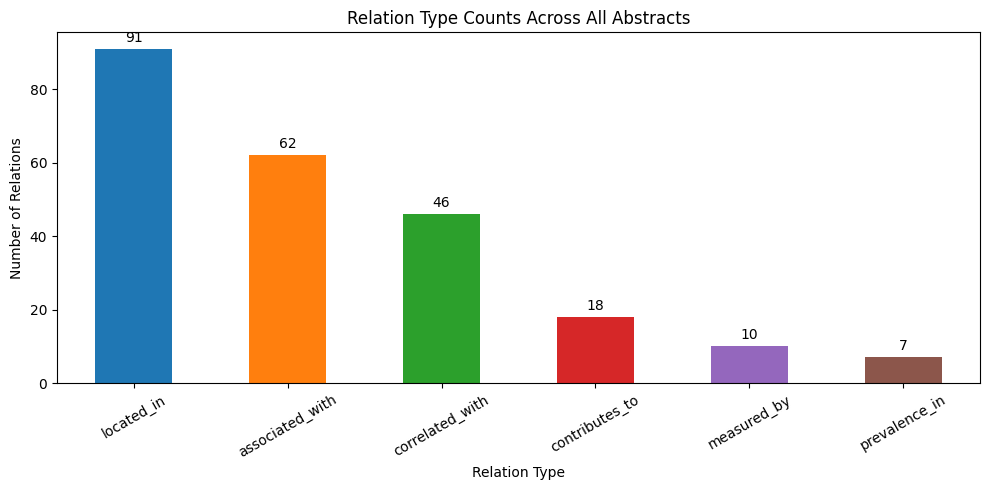

In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

relations_path = Path('LLMExtraction/relations_GPT5.json')
relations_raw = json.loads(relations_path.read_text(encoding='utf-8'))

relation_rows = []
for abstract_id, relation_list in relations_raw.items():
    for item in relation_list:
        relation_rows.append({
            'abstract_id': abstract_id,
            'subject': item.get('subject'),
            'relation': item.get('relation'),
            'object': item.get('object'),
            'evidence': item.get('evidence'),
        })

relations_df = pd.DataFrame(relation_rows)

articles_path = Path('Data/Flatfeet_clean.csv')
if not articles_path.exists():
    articles_path = Path('Flatfeet_clean.csv')

articles_df = pd.read_csv(articles_path)
articles_df['abstract_id'] = [f'abs_{i:03d}' for i in range(1, len(articles_df) + 1)]
abstracts_df = articles_df[['abstract_id', 'Abstract Note']].rename(
    columns={'Abstract Note': 'abstract_text'}
)

relations_with_abstracts = relations_df.merge(abstracts_df, on='abstract_id', how='left')

abstract_summary = (
    relations_with_abstracts.groupby('abstract_id')
    .agg(
        total_relations=('relation', 'size'),
        distinct_relation_types=('relation', 'nunique'),
        unique_subjects=('subject', 'nunique'),
        unique_objects=('object', 'nunique'),
        abstract_text=('abstract_text', 'first'),
    )
    .sort_values(['total_relations', 'distinct_relation_types'], ascending=False)
)

relation_type_counts = (
    relations_df['relation']
    .value_counts()
    .rename_axis('relation')
    .reset_index(name='count')
)

abstract_relation_matrix = pd.crosstab(relations_df['abstract_id'], relations_df['relation'])

print(f"Abstracts with extracted relations: {relations_df['abstract_id'].nunique()}")
print(f"Total extracted relations: {len(relations_df)}")
print(f"Distinct relation types: {relations_df['relation'].nunique()}")
print(f"Average relations per abstract: {len(relations_df) / relations_df['abstract_id'].nunique():.2f}")

display(relation_type_counts)
display(abstract_summary.head(10))
display(abstract_relation_matrix)

ax = relation_type_counts.sort_values('count', ascending=False).plot(
    kind='bar',
    x='relation',
    y='count',
    figsize=(10, 5),
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'],
    legend=False,
)
ax.set_title('Relation Type Counts Across All Abstracts')
ax.set_xlabel('Relation Type')
ax.set_ylabel('Number of Relations')
ax.tick_params(axis='x', rotation=30)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd

data = pd.read_csv('Data/Flatfeet_clean.csv')
abstracts = data['Abstract Note'].tolist()
abstracts

['Background: The collapse of medial longitudinal arch is called Flat Foot. In medical word, flat foot is associated with pronated foot. The prevalence of flatfoot is 17.1% in 7-14 years of age, 16.4% in 613 years and 17.2% in 6-12 years of age. Idiopathic anterior knee pain in nonathletic population without any history of any knee injury is mainly attributed to abnormal alignment and muscular imbalance. Flat foot is one of the contributing factors to development of anterior knee pain. Objective: The aim of present study is to find out the association between anterior knee pain and flat foot in young adults in Vadodara City. Method: Total 284 subjects were taken from the Vadodara city and assessed. Google form was created and circulated through digital media, Clarke’s Angle was measured from the foot print and Kujala Score was calculated from the Google form. Pearson Correlation test was used to analyse the data. Result: Result of the current study showed that there is negative correla